## Targets of this notebook
- find the anomalous behaviour within the dataset
- provide insights on data from ML perspecive (outlier-wise)
- serve as a first step towards anomaly detesction using Deep learning

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
from src.load_sam_data import load_dataset
dataset = load_dataset("data\\FJ\\FI01X1\\FI01X1_ch")

In [12]:
from models.knn_model import knnOutlierDetector
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

neigh = NearestNeighbors(n_neighbors=len(dataset))
neigh.fit(dataset)

neighborhood = []
for d in dataset:
    dist, _ = neigh.kneighbors([d], return_distance=True)
    neighborhood.append(dist)

avg_distances = [np.mean(dist) for dist in neighborhood]

mean = np.mean(avg_distances)
deviations = [abs(d-mean) for d in avg_distances]

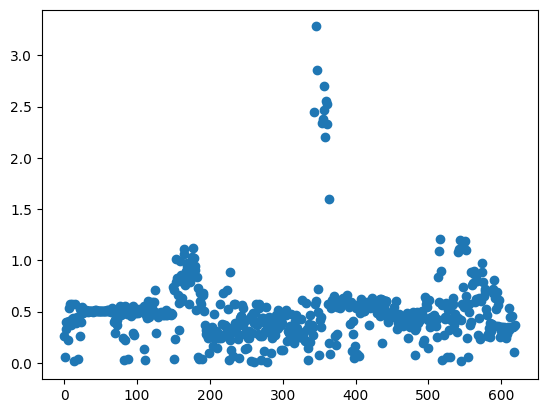

In [13]:
plt.scatter(range(len(deviations)), deviations)

# Is point 363 with score 1.6 an outlier?

In [32]:
possible_outlier =  [deviations.index(dev) for dev in deviations if dev < 2 and dev > 1.5]
possible_outlier

[363]

# Points that could be outliers

In [55]:
outliers_knn = [deviations.index(dev) for dev in deviations if dev > 1.5]
outliers_knn

[343, 346, 347, 354, 355, 356, 357, 358, 359, 360, 361, 363]

<BarContainer object of 96 artists>

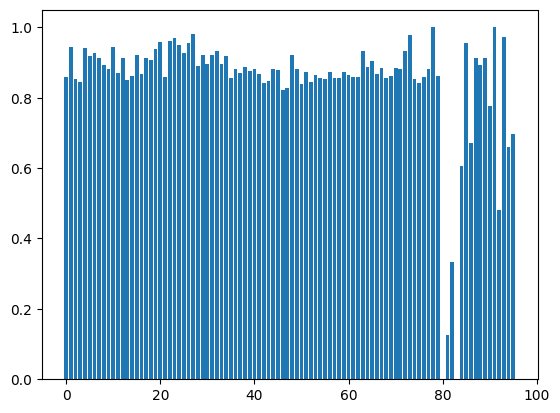

In [30]:
plt.bar(range(len(dataset[361])), dataset[361])

# Is point 113 outlier?

<BarContainer object of 96 artists>

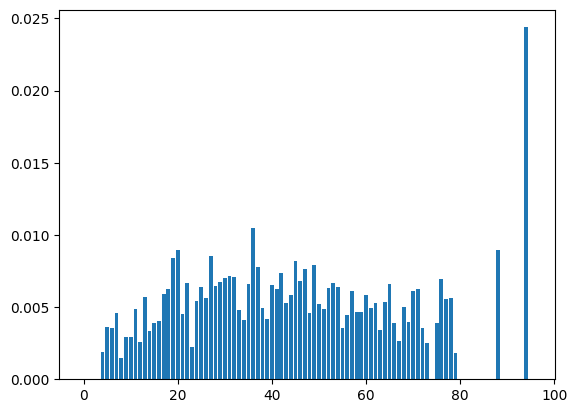

In [36]:
plt.bar(range(len(dataset[613])), dataset[113])

# Let's try OCSVM

In [40]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf').fit(dataset)
svm.fit_predict(dataset)
prediction = svm.predict(dataset)
out_measure = svm.score_samples(dataset)

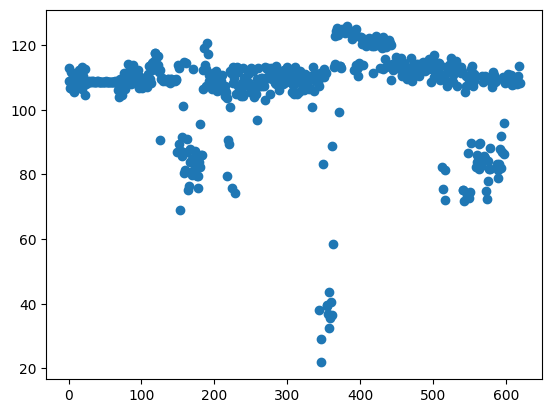

In [43]:
plt.scatter(range(len(out_measure)), out_measure)

In [79]:
outliers_svm = np.where(out_measure < 60)
outliers_svm = outliers_svm[0]

print("(SVM) Highest outlier score assigned to: ", np.where(out_measure == min(out_measure))[0].tolist())
print("(KNN) Highest outlier score assigned to: ", deviations.index(max(deviations)))
print(outliers_svm.tolist() == outliers_knn)
print(f"Outliers detected by svm {outliers_svm}")
print(f"Outliers detected by knn {outliers_knn}")


(SVM) Highest outlier score assigned to:  [346]
(KNN) Highest outlier score assigned to:  346
True
Outliers detected by svm [343 346 347 354 355 356 357 358 359 360 361 363]
Outliers detected by knn [343, 346, 347, 354, 355, 356, 357, 358, 359, 360, 361, 363]
